# 🏠 SOLUCIÓN DOCENTE — Regresión: Precio de Propiedades

**Curso:** Ciencia de Datos  
**Temas:** Modelado · Sesgo y Varianza · Explicabilidad · Equidad

> ⚠️ Este archivo es la solución de referencia para el docente.
> No distribuir a los alumnos antes de la entrega.

---
## Parte 0 — Setup y Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 110

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

In [3]:
def generar_dataset(n=600, seed=42):
    rng = np.random.default_rng(seed)
    n_a, n_b, n_c = n//3, n//3, n - 2*(n//3)

    def bloque(n_z, zona_label, m2_mu, ingreso_mu, dist_mu, premio):
        m2         = rng.normal(m2_mu, 20, n_z).clip(30, 300)
        cuartos    = rng.integers(1, 6, n_z).astype(float)
        banos      = (cuartos * rng.uniform(0.4, 0.8, n_z)).round().clip(1, 4)
        garage     = rng.binomial(1, 0.5 + 0.2*(zona_label=='A') - 0.1*(zona_label=='C'), n_z).astype(float)
        antiguedad = rng.uniform(0, 40, n_z).round()
        pisos      = rng.integers(1, 15, n_z).astype(float)
        ingreso_b  = rng.normal(ingreso_mu, 15, n_z).clip(20, 300)
        dist_c     = rng.normal(dist_mu, 2, n_z).clip(0.5, 30)
        zona       = np.array([zona_label] * n_z)
        precio = (
            800  * m2 + 18000 * cuartos + 12000 * banos
            + 25000 * garage - 800 * antiguedad + 500 * pisos
            + 300 * ingreso_b - 2000 * dist_c
            + premio + rng.normal(0, 15000, n_z)
        ) / 1000
        return pd.DataFrame({
            'm2': m2, 'cuartos': cuartos, 'banos': banos,
            'garage': garage, 'antiguedad': antiguedad, 'pisos': pisos,
            'ingreso_barrio': ingreso_b, 'dist_centro': dist_c,
            'zona': zona, 'precio': precio.clip(50)
        })

    df = pd.concat([
        bloque(n_a, 'A', m2_mu=110, ingreso_mu=180, dist_mu=3,  premio= 80000),
        bloque(n_b, 'B', m2_mu= 85, ingreso_mu=100, dist_mu=8,  premio=     0),
        bloque(n_c, 'C', m2_mu= 65, ingreso_mu= 50, dist_mu=15, premio=-60000),
    ], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

df = generar_dataset()
print(f"Dataset: {df.shape}")
print("\nDistribución por zona:")
print(df.groupby('zona')['precio'].agg(['count','mean','std']).round(1))

Dataset: (600, 10)

Distribución por zona:
      count   mean   std
zona                    
A       200  297.1  47.8
B       200  158.1  43.6
C       200   70.0  26.5


### Consigna 0.1 — EDA

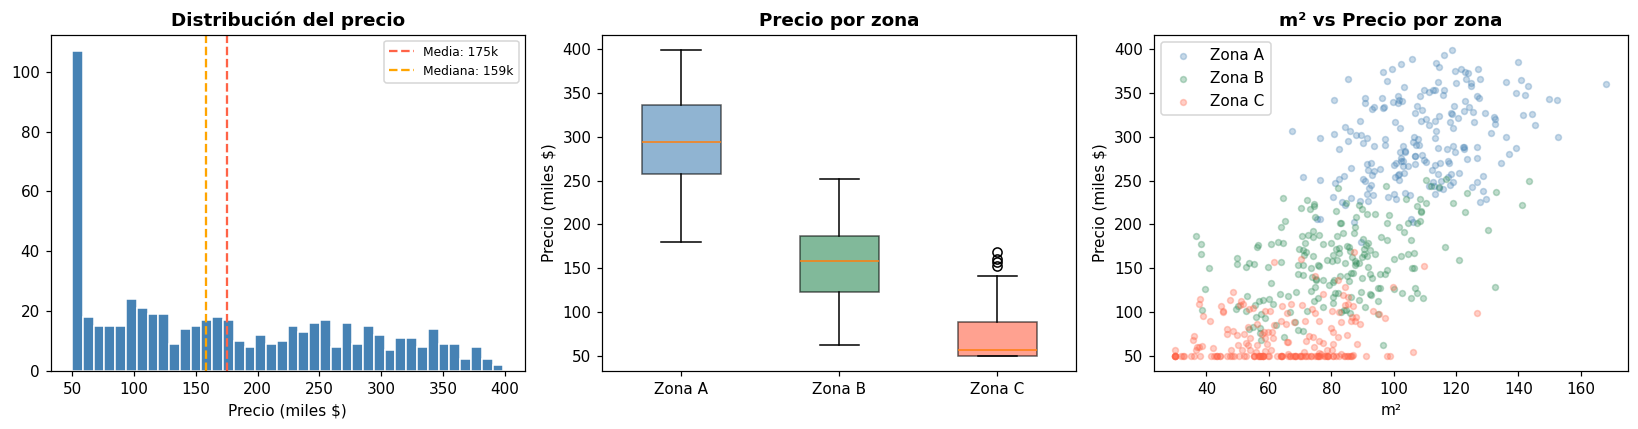

In [4]:
colores_zona = {'A': 'steelblue', 'B': 'seagreen', 'C': 'tomato'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# a. Distribución del precio
axes[0].hist(df['precio'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['precio'].mean(), color='tomato', linestyle='--', label=f'Media: {df["precio"].mean():.0f}k')
axes[0].axvline(df['precio'].median(), color='orange', linestyle='--', label=f'Mediana: {df["precio"].median():.0f}k')
axes[0].set_title('Distribución del precio', fontweight='bold')
axes[0].set_xlabel('Precio (miles $)')
axes[0].legend(fontsize=8)

# b. Boxplot por zona
for i, zona in enumerate(['A', 'B', 'C']):
    data = df[df['zona'] == zona]['precio']
    bp = axes[1].boxplot(data, positions=[i], widths=0.5, patch_artist=True,  boxprops=dict(facecolor=colores_zona[zona], alpha=0.6))

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Zona A', 'Zona B', 'Zona C'])
axes[1].set_title('Precio por zona', fontweight='bold')
axes[1].set_ylabel('Precio (miles $)')

# c. Scatter m2 vs precio por zona
for zona, color in colores_zona.items():
    sub = df[df['zona'] == zona]
    axes[2].scatter(sub['m2'], sub['precio'], alpha=0.3, s=15,
                    color=color, label=f'Zona {zona}')
axes[2].set_xlabel('m²')
axes[2].set_ylabel('Precio (miles $)')
axes[2].set_title('m² vs Precio por zona', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

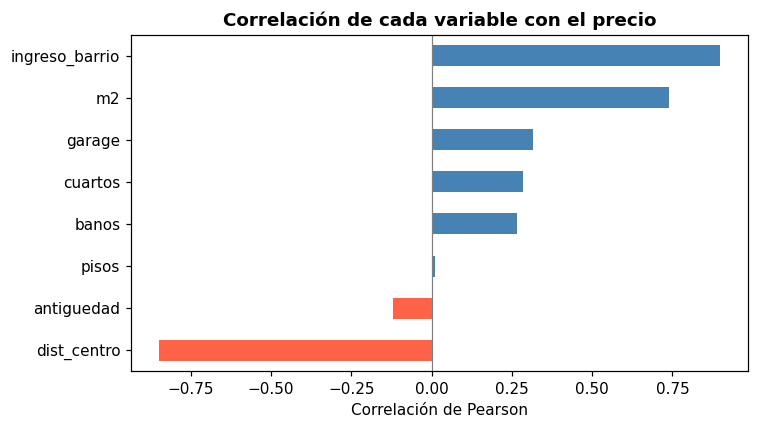


Estadísticas clave por zona:
      precio     m2  ingreso_barrio  dist_centro
zona                                            
A      297.1  109.4           180.6          3.1
B      158.1   82.6           100.8          8.1
C       70.0   64.6            51.5         14.8


In [5]:
# b. Correlaciones con el precio
numericas = df.select_dtypes(include='number')
corrs = numericas.corr()['precio'].drop('precio').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in corrs]
corrs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlación de cada variable con el precio', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

# c. Estadísticas por zona
print("\nEstadísticas clave por zona:")
print(df.groupby('zona')[['precio','m2','ingreso_barrio','dist_centro']]
        .mean().round(1).to_string())

**Interpretación esperada:**
- El precio tiene distribución asimétrica positiva (cola derecha), con media > mediana.
- Zona A tiene precios ~2x los de zona C, incluso con propiedades similares en m² (visible en el scatter).
- Las variables de mayor correlación con precio son `m2`, `ingreso_barrio` y `dist_centro`.
- `antiguedad` tiene correlación negativa esperada: a más antigüedad, menor precio.
- Las zonas difieren fuertemente en `ingreso_barrio` y `dist_centro`, lo que anticipa el problema de proxies en la Parte 4.

---
## Parte 1 — Modelado

In [6]:
features = ['m2', 'cuartos', 'banos', 'garage', 'antiguedad',  'pisos', 'ingreso_barrio', 'dist_centro']

df_enc = pd.get_dummies(df, columns=['zona'], drop_first=False)
features_con_zona = features + ['zona_A', 'zona_B', 'zona_C']

X = df_enc[features_con_zona]
y = df['precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

Train: (480, 11)   Test: (120, 11)


### Consigna 1.1 — Entrenar y comparar modelos

In [7]:
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Árbol (depth=5)':  DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred_tr = modelo.predict(X_train)
    pred_te = modelo.predict(X_test)
    resultados[nombre] = {
        'MAE train':  mean_absolute_error(y_train, pred_tr),
        'MAE test':   mean_absolute_error(y_test,  pred_te),
        'RMSE test':  np.sqrt(mean_squared_error(y_test, pred_te)),
        'R² test':    r2_score(y_test, pred_te),
        'Gap MAE':    mean_absolute_error(y_test, pred_te) - mean_absolute_error(y_train, pred_tr),
    }

df_res = pd.DataFrame(resultados).T.round(2)
print(df_res.to_string())

                  MAE train  MAE test  RMSE test  R² test  Gap MAE
Regresión Lineal      12.97     13.51      17.26     0.97     0.54
Árbol (depth=5)       13.71     16.44      22.60     0.95     2.73
Random Forest          5.38     12.62      18.02     0.97     7.24


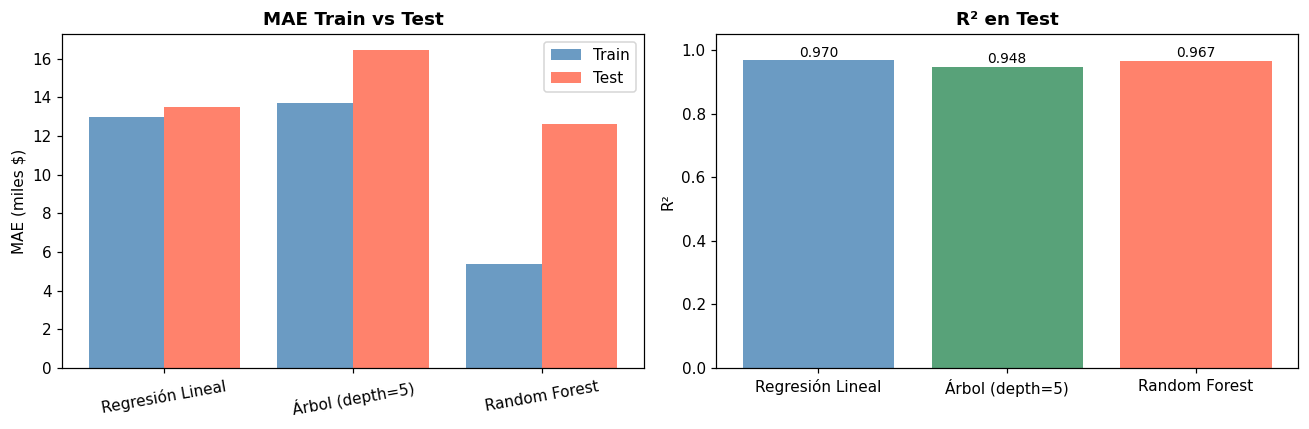

In [8]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nombres = list(resultados.keys())
mae_train = [resultados[n]['MAE train'] for n in nombres]
mae_test  = [resultados[n]['MAE test']  for n in nombres]
r2_test   = [resultados[n]['R² test']   for n in nombres]

x = np.arange(len(nombres))
axes[0].bar(x - 0.2, mae_train, 0.4, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + 0.2, mae_test,  0.4, label='Test',  color='tomato',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, rotation=10)
axes[0].set_ylabel('MAE (miles $)')
axes[0].set_title('MAE Train vs Test', fontweight='bold')
axes[0].legend()

axes[1].bar(nombres, r2_test, color=['steelblue','seagreen','tomato'], alpha=0.8)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('R²')
axes[1].set_title('R² en Test', fontweight='bold')
for i, v in enumerate(r2_test):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Consigna 2.1 — Estabilidad del modelo

Árbol  — R² media: 0.9357  std: 0.0134
RF     — R² media: 0.9663  std: 0.0058


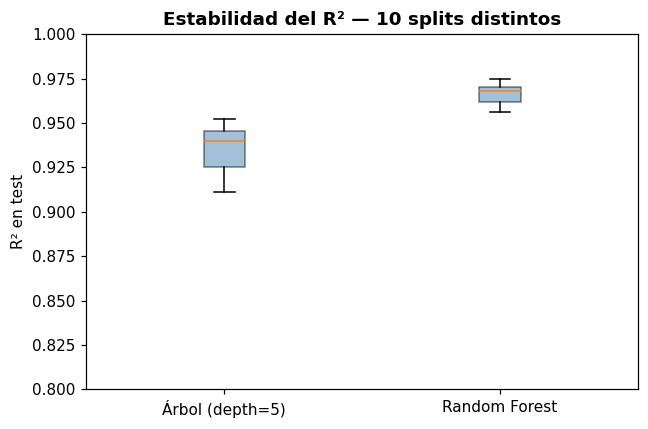

In [9]:
r2_arbol = []
r2_rf    = []

for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)

    arbol = DecisionTreeRegressor(max_depth=5, random_state=seed)
    arbol.fit(Xtr, ytr)
    r2_arbol.append(r2_score(yte, arbol.predict(Xte)))

    rf = RandomForestRegressor(n_estimators=100, random_state=seed)
    rf.fit(Xtr, ytr)
    r2_rf.append(r2_score(yte, rf.predict(Xte)))

print(f"Árbol  — R² media: {np.mean(r2_arbol):.4f}  std: {np.std(r2_arbol):.4f}")
print(f"RF     — R² media: {np.mean(r2_rf):.4f}  std: {np.std(r2_rf):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([r2_arbol, r2_rf], labels=['Árbol (depth=5)', 'Random Forest'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_ylabel('R² en test')
ax.set_title('Estabilidad del R² — 10 splits distintos', fontweight='bold')
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

**Interpretación esperada:**
- El árbol muestra mayor dispersión del R² entre splits: su rendimiento depende de qué datos caen en el train.
- El RF tiene std muy baja → alta estabilidad, confirmando que el promedio de árboles reduce la varianza del estimador.
- En producción, un modelo inestable es un riesgo: puede fallar inesperadamente con datos ligeramente distintos.

---
## Parte 3 — Explicabilidad con SHAP

In [10]:
import subprocess, sys
def install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
try:
    import shap
    from packaging.version import Version
    if Version(shap.__version__) < Version('0.46'):
        raise ImportError
except ImportError:
    install('shap>=0.46')
    import shap

# Reentrenar RF con el split original
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds_test = rf.predict(X_test)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer(X_test)
print(f"shap_values shape: {shap_values.values.shape}")

shap_values shape: (120, 11)


### Consigna 3.1 — Importancia global

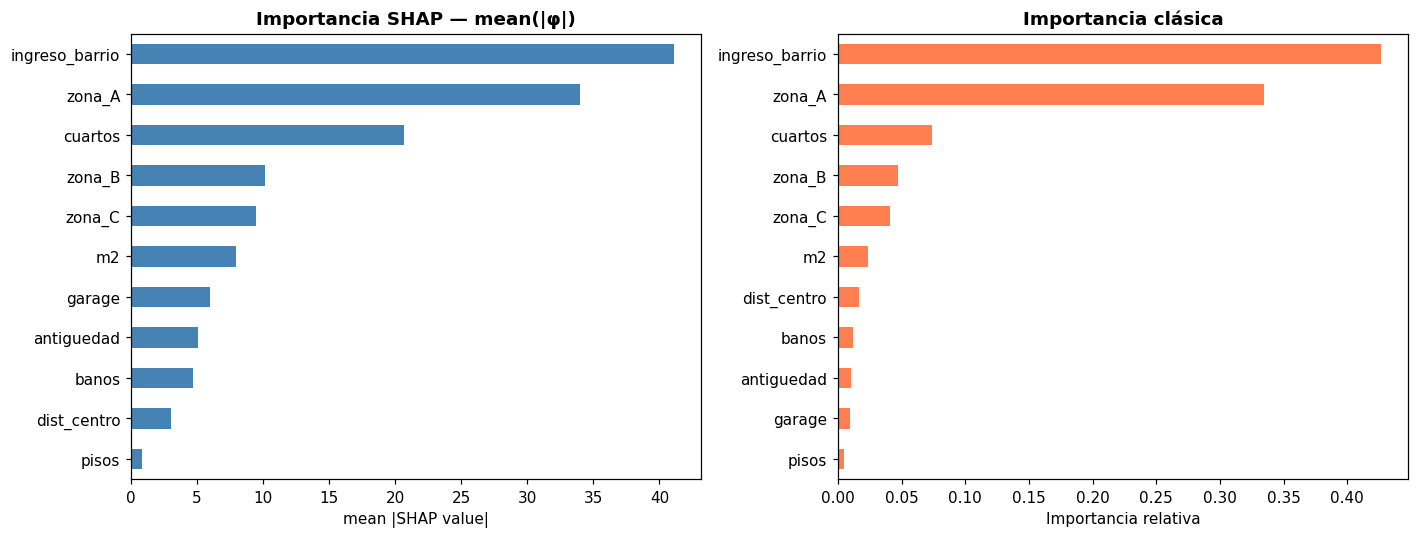

Top 5 SHAP:
ingreso_barrio    41.11
zona_A            33.97
cuartos           20.70
zona_B            10.17
zona_C             9.46


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SHAP importance
shap_mean = pd.Series( np.abs(shap_values.values).mean(axis=0), index=X_test.columns).sort_values()
shap_mean.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importancia SHAP — mean(|φ|)', fontweight='bold')
axes[0].set_xlabel('mean |SHAP value|')

# Feature importances clásica
fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
fi.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Importancia clásica', fontweight='bold')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

print("Top 5 SHAP:")
print(shap_mean.sort_values(ascending=False).head(5).round(2).to_string())

### Consigna 3.2 — Beeswarm

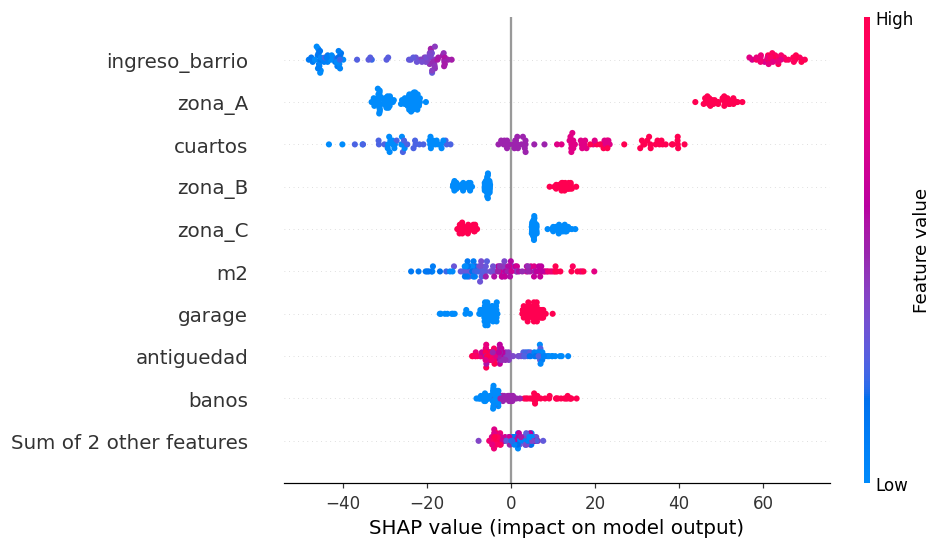

In [12]:
shap.plots.beeswarm(shap_values, show=True)

**Interpretación esperada:**
- `m2`: patrón monótono claro. Valores altos (rojo) → φ positivo; valores bajos (azul) → φ negativo.
- `antiguedad`: patrón monótono negativo. Casas más antiguas bajan el precio.
- `ingreso_barrio`: efecto positivo fuerte. Barrios de alto ingreso suben significativamente la predicción.
- `zona_A`: puntos rojos (zona_A=1) con φ positivo grande; `zona_C` al revés.
- El beeswarm revela la **distribución** del efecto, no solo el promedio — algo que el bar plot no muestra.

### Consigna 3.3 — Explicación individual

In [13]:
idx_max = preds_test.argmax()
idx_min = preds_test.argmin()

print("Propiedad más CARA:")
print(X_test.iloc[idx_max].to_frame().T.round(1).to_string())
print(f"  → Predicción: ${preds_test[idx_max]:,.1f}k")

print("\nPropiedad más BARATA:")
print(X_test.iloc[idx_min].to_frame().T.round(1).to_string())
print(f"  → Predicción: ${preds_test[idx_min]:,.1f}k")

Propiedad más CARA:
             m2 cuartos banos garage antiguedad pisos ingreso_barrio dist_centro zona_A zona_B zona_C
268  136.120035     5.0   2.0    1.0        8.0   3.0     194.439864    4.124546   True  False  False
  → Predicción: $367.5k

Propiedad más BARATA:
            m2 cuartos banos garage antiguedad pisos ingreso_barrio dist_centro zona_A zona_B zona_C
535  58.096863     1.0   1.0    0.0       17.0  11.0      52.273848    13.17089  False  False   True
  → Predicción: $50.0k


Waterfall — Propiedad MÁS CARA ($367.5k)


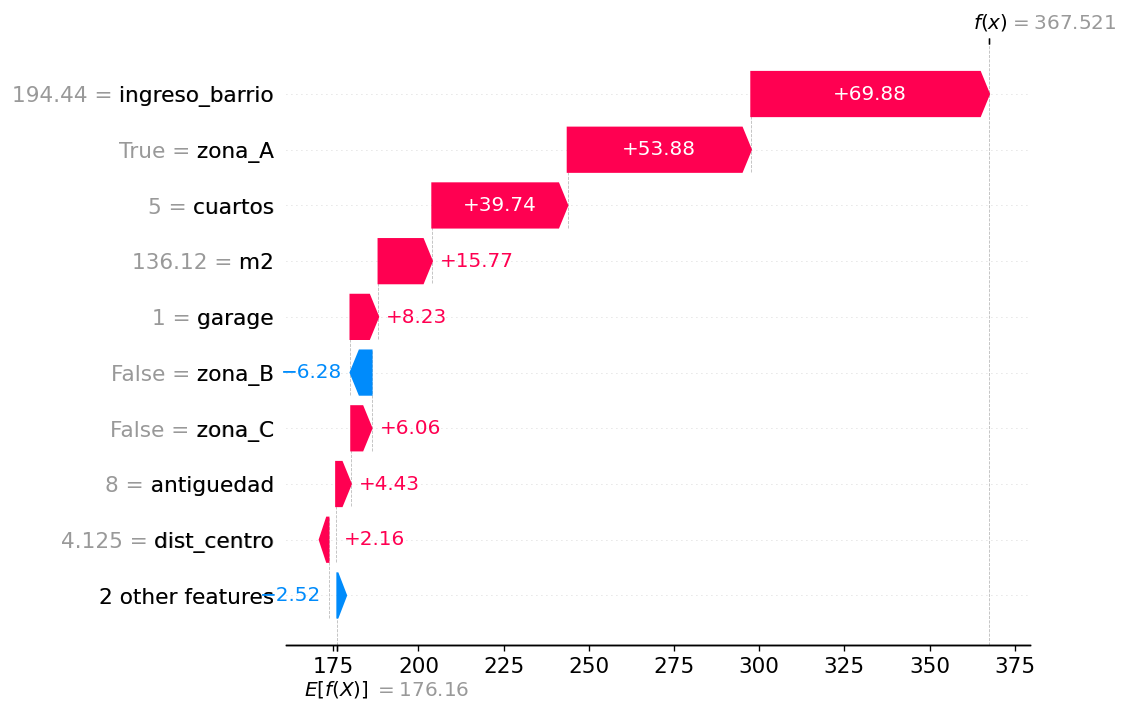

In [14]:
matplotlib.rcParams['figure.dpi'] = 120
print(f"Waterfall — Propiedad MÁS CARA (${preds_test[idx_max]:,.1f}k)")
shap.plots.waterfall(shap_values[idx_max], show=True)

Waterfall — Propiedad MÁS BARATA ($50.0k)


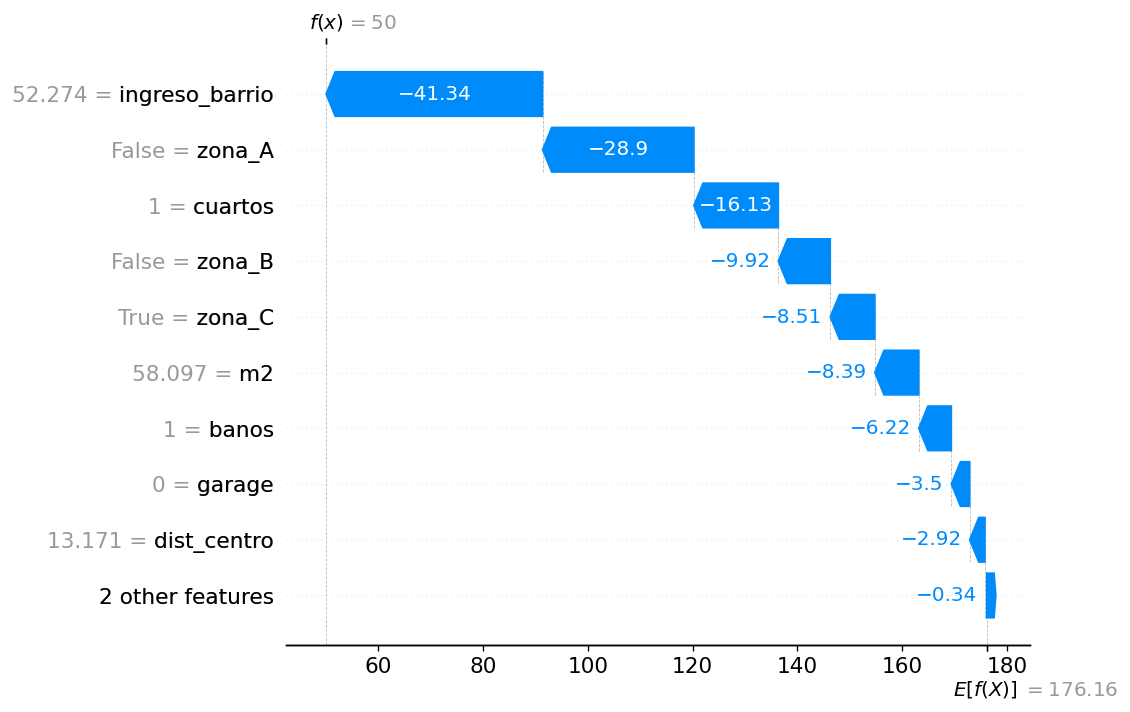

In [14]:
print(f"Waterfall — Propiedad MÁS BARATA (${preds_test[idx_min]:,.1f}k)")
shap.plots.waterfall(shap_values[idx_min], show=True)

---
## Parte 4 — Equidad (Fairness)

In [15]:
idx_test  = y_test.index
zona_test = df.loc[idx_test, 'zona'].values
residuos  = y_test.values - preds_test

### Consigna 4.1 — Error por grupo

In [16]:
filas = []
for zona in ['A', 'B', 'C']:
    mask = zona_test == zona
    yt   = y_test.values[mask]
    yp   = preds_test[mask]
    filas.append({
        'Zona':              zona,
        'N':                 mask.sum(),
        'MAE':               mean_absolute_error(yt, yp),
        'RMSE':              np.sqrt(mean_squared_error(yt, yp)),
        'R²':                r2_score(yt, yp),
        'Residuo promedio':  np.mean(yt - yp),
    })

df_fair = pd.DataFrame(filas).set_index('Zona')
print(df_fair.round(2).to_string())

       N    MAE   RMSE    R²  Residuo promedio
Zona                                          
A     37  15.20  20.25  0.82             -2.40
B     43  15.35  20.86  0.80             -2.90
C     40   7.30  11.26  0.81             -1.79


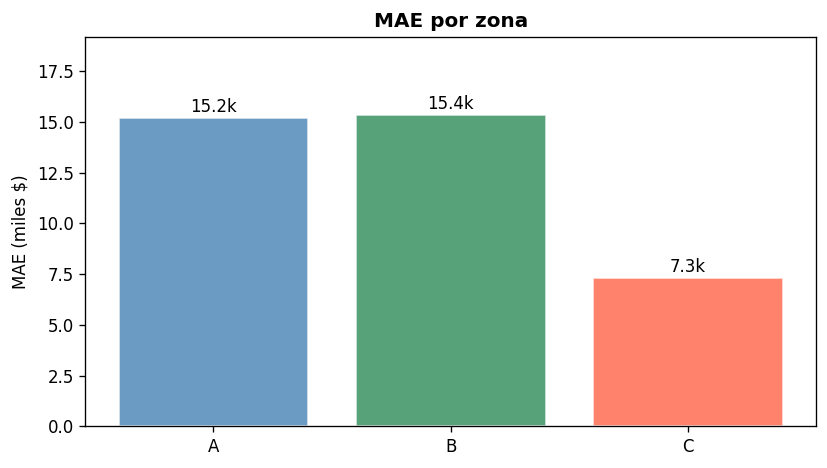

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
colores = ['steelblue', 'seagreen', 'tomato']
zonas   = ['A', 'B', 'C']
mae_vals = [df_fair.loc[z, 'MAE'] for z in zonas]
bars = ax.bar(zonas, mae_vals, color=colores, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}k', ha='center', fontsize=10)
ax.set_title('MAE por zona', fontweight='bold')
ax.set_ylabel('MAE (miles $)')
ax.set_ylim(0, max(mae_vals)*1.25)
plt.tight_layout()
plt.show()

### Consigna 4.2 — Distribución de residuos por zona

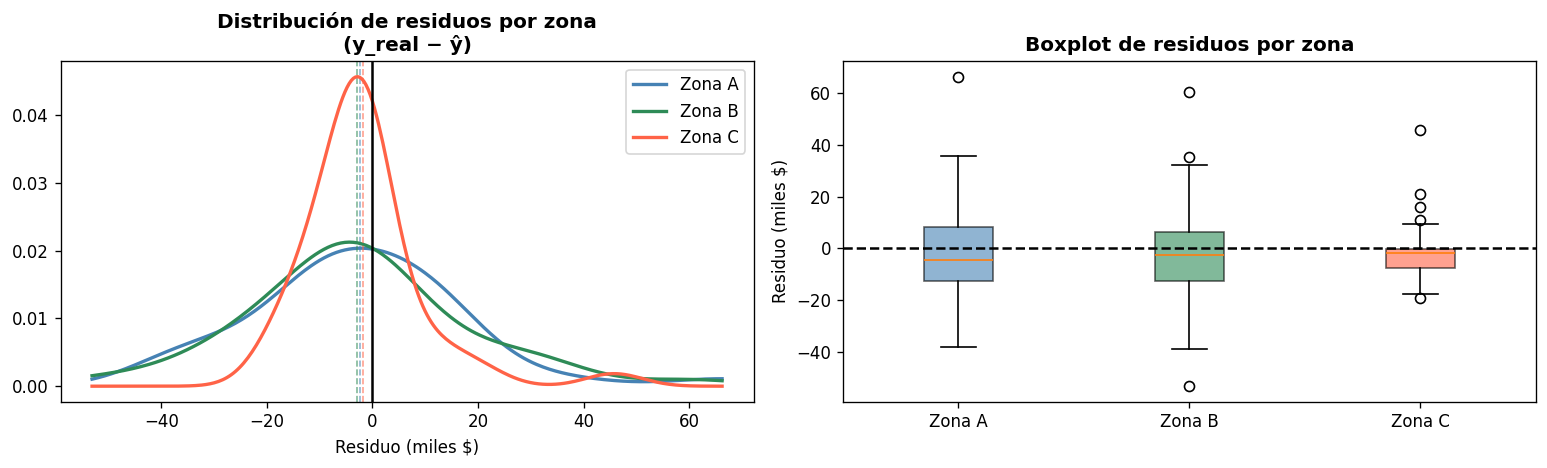

In [18]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores_zona = {'A': 'steelblue', 'B': 'seagreen', 'C': 'tomato'}

# KDE de residuos
for zona, color in colores_zona.items():
    mask = zona_test == zona
    res  = residuos[mask]
    kde  = gaussian_kde(res)
    xr   = np.linspace(residuos.min(), residuos.max(), 300)
    axes[0].plot(xr, kde(xr), color=color, linewidth=2, label=f'Zona {zona}')
    axes[0].axvline(res.mean(), color=color, linestyle='--', alpha=0.6, linewidth=1)

axes[0].axvline(0, color='black', linewidth=1.5, linestyle='-')
axes[0].set_title('Distribución de residuos por zona\n(y_real − ŷ)', fontweight='bold')
axes[0].set_xlabel('Residuo (miles $)')
axes[0].legend()

# Boxplot
data_boxplot = [residuos[zona_test == z] for z in ['A', 'B', 'C']]
bp = axes[1].boxplot(data_boxplot, labels=['Zona A', 'Zona B', 'Zona C'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], colores_zona.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Boxplot de residuos por zona', fontweight='bold')
axes[1].set_ylabel('Residuo (miles $)')

plt.tight_layout()
plt.show()

---
## Parte 5 — Análisis con librerías especializadas

### 5.1 — Sesgo y varianza con `mlxtend`

`bias_variance_decomp` con `loss='mse'` descompone el error cuadrático medio en sus componentes:

$$\text{MSE} \approx \text{Bias}^2 + \text{Varianza}$$

In [18]:
!pip install mlxtend -q

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\python\\python312\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from mlxtend.evaluate import bias_variance_decomp

modelos_bv = {
    'Árbol (depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':   RandomForestRegressor(n_estimators=100, random_state=42),
}

print(f"{'Modelo':<20} {'Loss (MSE)':>12} {'Bias':>10} {'Varianza':>10}")
print('-' * 54)
for nombre, modelo in modelos_bv.items():
    loss, bias, var = bias_variance_decomp(
        modelo,
        X_train.values, y_train.values,
        X_test.values,  y_test.values,
        loss='mse', random_seed=42
    )
    print(f"{nombre:<20} {loss:>12.2f} {bias:>10.2f} {var:>10.2f}")

Modelo                 Loss (MSE)       Bias   Varianza
------------------------------------------------------
Árbol (depth=5)            751.35     398.15     353.20
Random Forest              434.55     340.33      94.22


**Interpretación esperada:**

| Modelo | Loss (MSE) | Bias | Varianza |
|--------|-----------|------|----------|
| Árbol (depth=5) | 751.35 | 398.15 | 353.20 |
| Random Forest | 434.51 | 340.31 | 94.20 |

- El RF reduce la varianza a menos de un tercio (353 → 94) — el efecto principal del promedio de árboles.
- El bias también mejora pero en menor medida (398 → 340).
- Confirma lo visto en la consigna 2.1: la ganancia del RF sobre el árbol viene principalmente de estabilizar las predicciones, no de reducir el error sistemático.

### 5.2 — Equidad con `dalex`

Para regresión, `dalex` calcula métricas de error por grupo y las compara contra el grupo de referencia.

| Métrica | Descripción |
|---------|-------------|
| **independence** | Ratio de MSE entre grupos |
| **separation** | Ratio de MAE entre grupos |
| **sufficiency** | Ratio de correlación predicción-real entre grupos |

Si el ratio cae fuera del intervalo $(\epsilon, 1/\epsilon)$ con $\epsilon=0.8$, detecta sesgo.

In [ ]:
!pip install dalex -q

### Métricas de equidad en regresión

`dalex` compara cada métrica contra el grupo de referencia (**Zona A**) mediante ratios.
Si el ratio cae fuera del intervalo $(\epsilon,\ 1/\epsilon)$ con $\epsilon = 0.8$, es decir fuera de $(0.8,\ 1.25)$, se detecta sesgo.

---

### Independence

$$\text{independence}_{\text{grupo}} = \frac{\text{MSE}_{\text{grupo}}}{\text{MSE}_{\text{Zona A}}}$$

Mide si el modelo comete errores igualmente grandes en todos los grupos, **sin importar el valor real**.  
Idealmente el error del modelo debería ser **independiente** del grupo al que pertenece la observación.

| Valor | Interpretación |
|-------|---------------|
| $= 1$ | El grupo tiene exactamente el mismo MSE que Zona A — equidad perfecta |
| $< 1$ | El grupo tiene **menor** MSE que Zona A — el modelo es más preciso en ese grupo |
| $> 1$ | El grupo tiene **mayor** MSE que Zona A — el modelo comete errores más grandes en ese grupo |
| $\gg 1$ | Sesgo severo — el modelo es mucho menos preciso para ese grupo |

---

### Separation

$$\text{separation}_{\text{grupo}} = \frac{\text{MAE}_{\text{grupo}}}{\text{MAE}_{\text{Zona A}}}$$

Mide si el modelo comete errores igualmente grandes **dado el valor real**.  
Usa MAE en lugar de MSE para ser menos sensible a outliers.  
Evalúa si el modelo **separa** bien predicción de realidad de forma uniforme entre grupos.

| Valor | Interpretación |
|-------|---------------|
| $= 1$ | El error absoluto promedio es igual al de Zona A — equidad perfecta |
| $< 1$ | El modelo es más preciso en ese grupo que en Zona A |
| $> 1$ | El modelo comete errores absolutos más grandes en ese grupo |
| $> 1.25$ | Fuera del rango aceptable — sesgo detectado |

---

### Sufficiency

$$\text{sufficiency}_{\text{grupo}} = \frac{\text{corr}(\hat{y},\ y)_{\text{grupo}}}{\text{corr}(\hat{y},\ y)_{\text{Zona A}}}$$

Mide si la predicción es igualmente **informativa** del valor real en cada grupo.  
Evalúa si la predicción sola es **suficiente** para estimar el valor real sin importar el grupo.

| Valor | Interpretación |
|-------|---------------|
| $= 1$ | La predicción es igual de informativa que en Zona A — equidad perfecta |
| $< 1$ | La predicción es **menos** informativa en ese grupo — el modelo explica menos variabilidad |
| $> 1$ | La predicción es **más** informativa en ese grupo que en Zona A |
| fuera de $(0.8,\ 1.25)$ | Sesgo detectado — la utilidad de la predicción difiere entre grupos |

---

In [22]:
import dalex as dx

exp = dx.Explainer(rf, X_test.copy(), y_test.copy(), verbose=False, model_type='regression')

# Variable sensible: zona del test set
protected = np.where(zona_test=='A', 'Zona_A',  np.where(zona_test=='B', 'Zona_B', 'Zona_C')  )
privileged = 'Zona_C'  #Grupo de referencia

fobject = exp.model_fairness(protected=protected, privileged=privileged)
fobject.fairness_check()

Bias detected in 2 metrics: independence, separation

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Zona_C'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
          independence  separation  sufficiency
subgroup                                       
Zona_A       11.633460    1.252555     1.159016
Zona_B        7.491176    1.453900     0.964489


El modelo predice el precio de propiedades de Zona A con mucha más precisión que el de las otras zonas. Zona A tiene características muy distintivas (ingreso alto, cerca del centro) que el modelo aprende fácilmente.

In [21]:
fobject.plot()